In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.svm import LinearSVR
from sklearn.model_selection import StratifiedKFold
from scipy.ndimage import gaussian_filter1d
from scipy.stats import spearmanr
from joblib import Parallel, delayed
import time as tm
import pickle

mne.set_log_level('WARNING')
%matplotlib inline

print(f'numpy: {np.__version__}')
print(f'mne: {mne.__version__}')

numpy: 1.26.4
mne: 1.12.1


In [ ]:
# ruta donde estan las carpetas de cada sujeto
data_dir = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/'

subjs_list = sorted([
    d for d in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, d)) and d.startswith('s')
])
print(f'Sujetos encontrados ({len(subjs_list)}): {subjs_list}')

Sujetos encontrados (28): ['s01', 's02', 's03', 's04', 's05', 's06', 's07', 's08', 's09', 's0x', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21', 's22', 's23', 's24', 's25', 's26', 's27']


In [4]:
# cargamos solo main_epo.fif
all_main_epochs  = []
all_main_rawdata = []
subjs_ok         = []

for subject_id in subjs_list:
    subj_path = os.path.join(data_dir, subject_id)
    file_main = os.path.join(subj_path, 'main_epo.fif')

    if not os.path.exists(file_main):
        print(f'  {subject_id}: falta main_epo.fif, se omite')
        continue

    try:
        main = mne.read_epochs(file_main, preload=True, verbose=False)
        all_main_epochs.append(main)
        all_main_rawdata.append({
            'epoch_dat': main.get_data(),
            'metadata':  main.metadata
        })
        subjs_ok.append(subject_id)
        print(f'  {subject_id} cargado — shape: {main.get_data().shape}')
    except Exception as e:
        print(f'  {subject_id}: error al cargar → {e}')

nSubj  = len(subjs_ok)
time   = all_main_epochs[0].times
n_time = len(time)
print(f'\nTotal sujetos cargados: {nSubj}')
print(f'Timepoints: {n_time}  |  Ventana: {time[0]:.2f}s → {time[-1]:.2f}s')

  s01 cargado — shape: (250, 32, 2876)
  s02 cargado — shape: (261, 32, 2876)
  s03 cargado — shape: (256, 32, 2876)
  s04 cargado — shape: (236, 32, 2876)
  s05 cargado — shape: (243, 32, 2876)
  s06: falta main_epo.fif, se omite
  s07 cargado — shape: (249, 32, 2876)
  s08 cargado — shape: (247, 32, 2876)
  s09 cargado — shape: (193, 32, 2876)
  s0x: falta main_epo.fif, se omite
  s10 cargado — shape: (250, 32, 2876)
  s11 cargado — shape: (251, 32, 2876)
  s12 cargado — shape: (252, 32, 2876)
  s13 cargado — shape: (253, 32, 2876)
  s14 cargado — shape: (261, 32, 2876)
  s15 cargado — shape: (257, 32, 2876)
  s16 cargado — shape: (238, 32, 2876)
  s17 cargado — shape: (260, 32, 2876)
  s18 cargado — shape: (239, 32, 2876)
  s19 cargado — shape: (259, 32, 2876)
  s20 cargado — shape: (248, 32, 2876)
  s21 cargado — shape: (257, 32, 2876)
  s22 cargado — shape: (264, 32, 2876)
  s23 cargado — shape: (255, 32, 2876)
  s24 cargado — shape: (232, 32, 2876)
  s25 cargado — shape: (264, 32

In [5]:
# canales centrales — los mas informativos para la decision
all_ch_names = all_main_epochs[0].ch_names
central_ch   = ['C3', 'C4', 'Cz', 'CP1', 'CP2', 'CP5', 'CP6']
central_idx  = [all_ch_names.index(ch) for ch in central_ch]

n_folds = 5
nreps   = [0, 1, 2]  # P1, P2, P3

# colores para P1, P2, P3
colors_nrep  = ['#1a3a6e', '#2e7bbf', '#7ec8e3']
labels_nrep  = ['P1 (nrep=0)', 'P2 (nrep=1)', 'P3 (nrep=2)']

# funcion para crear folds estratificados
def create_folds(y_binned, n_folds=5):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    folds = []
    dummy_X = np.zeros(len(y_binned))
    for train_idx, test_idx in skf.split(dummy_X, y_binned):
        folds.append({'train_index': train_idx, 'test_index': test_idx})
    return folds

# funcion que procesa un solo timepoint para decision (LDA)
def decode_timepoint_deci(it, Y, labels, folds):
    import warnings
    warnings.filterwarnings('ignore')
    Ytime  = Y[:, :, it]
    scaler = StandardScaler().fit(Ytime)
    Ytime  = scaler.transform(Ytime)
    preds  = np.full(len(labels), np.nan)
    clf    = LinearDiscriminantAnalysis()
    for fold in folds:
        train_ix = fold['train_index']
        test_ix  = fold['test_index']
        if len(np.unique(labels[train_ix])) < 2:
            continue
        clf.fit(Ytime[train_ix], labels[train_ix])
        preds[test_ix] = clf.predict(Ytime[test_ix])
    return preds

# funcion que procesa un solo timepoint para orientacion (AngularRegression)
class AngularRegression(BaseEstimator, RegressorMixin):
    def __init__(self, clf=None):
        self.clf = clf if clf is not None else LinearSVR()
    def fit(self, X, y):
        self.clf_cos = clone(self.clf)
        self.clf_sin = clone(self.clf)
        self.clf_cos.fit(X, np.cos(2 * y))
        self.clf_sin.fit(X, np.sin(2 * y))
        return self
    def predict(self, X):
        cos_pred = self.clf_cos.predict(X)
        sin_pred = self.clf_sin.predict(X)
        return np.arctan2(sin_pred, cos_pred) / 2

def scorer_angle(y_true, y_pred):
    error = 2 * y_true - 2 * y_pred
    return np.mean(np.cos(error))

def decode_timepoint_ori(it, Y, phi, folds):
    import warnings
    warnings.filterwarnings('ignore')
    Ytime  = Y[:, :, it]
    scaler = StandardScaler().fit(Ytime)
    Ytime  = scaler.transform(Ytime)
    preds  = np.full(len(phi), np.nan)
    clf    = AngularRegression(clf=LinearSVR(max_iter=5000, C=0.1))
    for fold in folds:
        train_ix = fold['train_index']
        test_ix  = fold['test_index']
        clf.fit(Ytime[train_ix], phi[train_ix])
        preds[test_ix] = clf.predict(Ytime[test_ix])
    return preds

print('parametros y funciones definidos')
print(f'Canales centrales: {central_ch}')

parametros y funciones definidos
Canales centrales: ['C3', 'C4', 'Cz', 'CP1', 'CP2', 'CP5', 'CP6']



subj s01 (1/26)
  P1 (nrep=0) ✓  P2 (nrep=1) ✓  P3 (nrep=2) ✓  → 0.2 min transcurridos

subj s02 (2/26)
  P1 (nrep=0) ✓  P2 (nrep=1) ✓  P3 (nrep=2) ✓  → 0.3 min transcurridos

subj s03 (3/26)
  P1 (nrep=0) ✓  P2 (nrep=1) ✓  P3 (nrep=2) ✓  → 0.4 min transcurridos

subj s04 (4/26)
  P1 (nrep=0) ✓  P2 (nrep=1) ✓  P3 (nrep=2) ✓  → 0.5 min transcurridos

subj s05 (5/26)
  P1 (nrep=0) ✓  P2 (nrep=1) ✓  P3 (nrep=2) ✓  → 0.7 min transcurridos

subj s07 (6/26)
  P1 (nrep=0) ✓  P2 (nrep=1) ✓  P3 (nrep=2) ✓  → 0.8 min transcurridos

subj s08 (7/26)
  P1 (nrep=0) ✓  P2 (nrep=1) ✓  P3 (nrep=2) ✓  → 0.9 min transcurridos

subj s09 (8/26)
  P1 (nrep=0) ✓  P2 (nrep=1) ✓  P3 (nrep=2) ✓  → 1.1 min transcurridos

subj s10 (9/26)
  P1 (nrep=0) ✓  P2 (nrep=1) ✓  P3 (nrep=2) ✓  → 1.2 min transcurridos

subj s11 (10/26)
  P1 (nrep=0) ✓  P2 (nrep=1) ✓  P3 (nrep=2) ✓  → 1.3 min transcurridos

subj s12 (11/26)
  P1 (nrep=0) ✓  P2 (nrep=1) ✓  P3 (nrep=2) ✓  → 1.5 min transcurridos

subj s13 (12/26)
  P1 (nrep=0

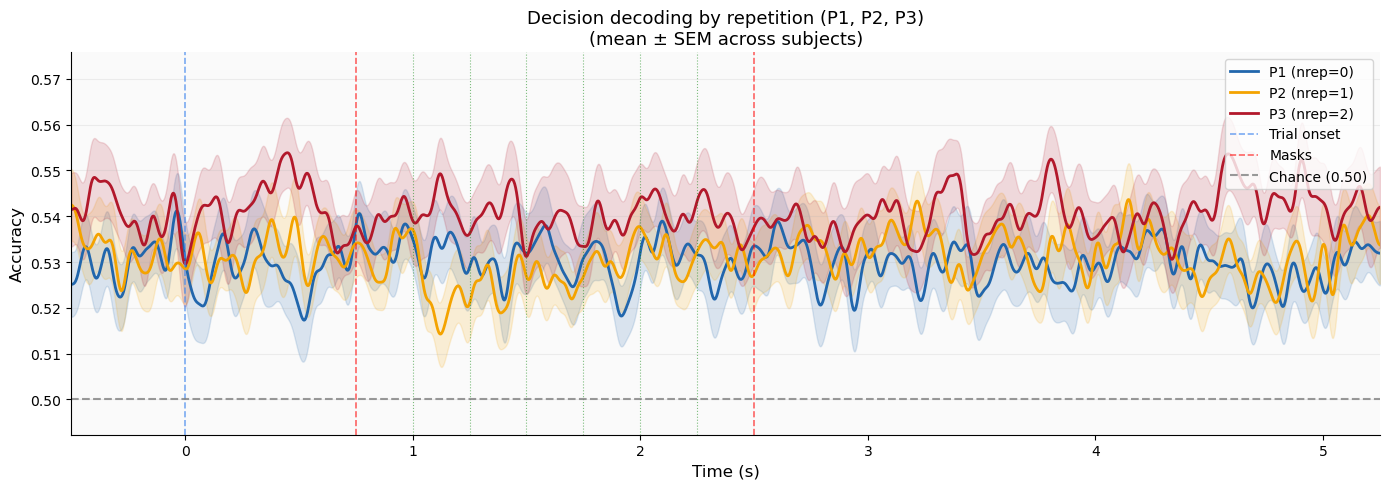

In [ ]:
# DECODING DE DECISION SEPARADO POR P1, P2, P3 
# el tutor señala que al mezclar todas las repeticiones, el efecto de que en P2
# y P3 el participante ya conoce la secuencia contamina el periodo pre-estimulo
# en P1 (primera vez que ve la secuencia), antes de los estimulos NO deberia
# haber informacion predictiva sobre la decision
# si la hay en P2 y P3, es evidencia directa del sesgo de confirmacion

# definimos las etiquetas y colores ANTES del loop para que no se sobreescriban
plot_labels = ['P1 (nrep=0)', 'P2 (nrep=1)', 'P3 (nrep=2)']
plot_colors = ['#2166ac', '#f4a300', '#b2182b']

# array donde guardamos la accuracy (n_nreps × n_sujetos × n_timepoints)
scorer_deci_nrep = np.zeros((len(nreps), nSubj, n_time))

t_start = tm.time()

for isubj in range(nSubj):
    print(f'\nsubj {subjs_ok[isubj]} ({isubj+1}/{nSubj})')

    Y        = all_main_rawdata[isubj]['epoch_dat']
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)
    deci     = np.array(metadata['deci'], dtype=int)  # renombramos a deci para no confundir

    for i_nrep, nrep in enumerate(nreps):
        # seleccionamos solo los trials de este nrep
        idx_nrep    = metadata[metadata['nrep'] == nrep].index.tolist()
        if len(idx_nrep) < n_folds * 2:
            print(f'  nrep={nrep}: pocos trials ({len(idx_nrep)}), se omite')
            continue

        Y_nrep    = Y[idx_nrep]
        deci_nrep = deci[idx_nrep]  # usamos deci_nrep en vez de labels_nrep

        if len(np.unique(deci_nrep)) < 2:
            continue

        folds = create_folds(deci_nrep, n_folds)

        # procesamos todos los timepoints en paralelo
        results_par = Parallel(n_jobs=-1)(
            delayed(decode_timepoint_deci)(it, Y_nrep, deci_nrep, folds)
            for it in range(n_time)
        )

        preds_all = np.column_stack(results_par)

        for it in range(n_time):
            valid = ~np.isnan(preds_all[:, it])
            scorer_deci_nrep[i_nrep, isubj, it] = np.mean(
                preds_all[valid, it] == deci_nrep[valid].astype(float)
            )

        print(f'  P{nrep+1} (nrep={nrep}) ✓', end='', flush=True)

    elapsed = (tm.time() - t_start) / 60
    print(f'  → {elapsed:.1f} min transcurridos')

print(f'\ndecoding de decision por P1/P2/P3 completado')

# guardamos resultados
results = {
    'scorer_deci_nrep': scorer_deci_nrep,
    'time':             time,
    'subjs_ok':         subjs_ok,
}
save_path = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/key_decoding_deci_nrep.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(results, f)
print(f'resultados guardados en: {save_path}')

# plot — tres lineas P1, P2, P3
sigma = 10
scorer_smooth = gaussian_filter1d(scorer_deci_nrep, sigma=sigma, axis=2)

fig, ax = plt.subplots(figsize=(14, 5))

for i_nrep in range(len(nreps)):
    mean = np.mean(scorer_smooth[i_nrep], axis=0)
    sem  = np.std(scorer_smooth[i_nrep], axis=0) / np.sqrt(nSubj)
    ax.plot(time, mean, color=plot_colors[i_nrep], lw=2, label=plot_labels[i_nrep])
    ax.fill_between(time, mean - sem, mean + sem, color=plot_colors[i_nrep], alpha=0.15)

ax.axvline(0,                color='#4488EE', ls='--', lw=1.2, alpha=0.7, label='Trial onset')
ax.axvline(0.75,             color='red',     ls='--', lw=1.2, alpha=0.6, label='Masks')
ax.axvline(0.75 + 0.25 * 7, color='red',     ls='--', lw=1.2, alpha=0.6)
for istim in range(6):
    ax.axvline(0.75 + 0.25 * (istim + 1), color='green', ls=':', lw=0.8, alpha=0.5)

ax.axhline(0.5, color='gray', ls='--', lw=1.5, alpha=0.8, label='Chance (0.50)')

all_means = [np.mean(scorer_smooth[i], axis=0) for i in range(len(nreps))]
all_sems  = [np.std(scorer_smooth[i], axis=0) / np.sqrt(nSubj) for i in range(len(nreps))]
y_min = min(m.min() for m in all_means) - max(s.max() for s in all_sems) - 0.01
y_max = max(m.max() for m in all_means) + max(s.max() for s in all_sems) + 0.01
ax.set_ylim([max(0.45, y_min), min(0.70, y_max)])
ax.set_xlim([-0.5, 5.25])

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Decision decoding by repetition (P1, P2, P3)\n'
             '(mean ± SEM across subjects)', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()


subj s01 (1/26)
  P1 ✓  P2 ✓  P3 ✓  → 1.1 min transcurridos

subj s02 (2/26)
  P1 ✓  P2 ✓  P3 ✓  → 2.2 min transcurridos

subj s03 (3/26)
  P1 ✓  P2 ✓  P3 ✓  → 3.1 min transcurridos

subj s04 (4/26)
  P1 ✓  P2 ✓  P3 ✓  → 4.0 min transcurridos

subj s05 (5/26)
  P1 ✓  P2 ✓  P3 ✓  → 4.8 min transcurridos

subj s07 (6/26)
  P1 ✓  P2 ✓  P3 ✓  → 5.7 min transcurridos

subj s08 (7/26)
  P1 ✓  P2 ✓  P3 ✓  → 6.6 min transcurridos

subj s09 (8/26)
  P1 ✓  P2 ✓  P3 ✓  → 7.4 min transcurridos

subj s10 (9/26)
  P1 ✓  P2 ✓  P3 ✓  → 8.4 min transcurridos

subj s11 (10/26)
  P1 ✓  P2 ✓  P3 ✓  → 9.3 min transcurridos

subj s12 (11/26)
  P1 ✓  P2 ✓  P3 ✓  → 10.2 min transcurridos

subj s13 (12/26)
  P1 ✓  P2 ✓  P3 ✓  → 11.2 min transcurridos

subj s14 (13/26)
  P1 ✓  P2 ✓  P3 ✓  → 12.0 min transcurridos

subj s15 (14/26)
  P1 ✓  P2 ✓  P3 ✓  → 13.0 min transcurridos

subj s16 (15/26)
  P1 ✓  P2 ✓  P3 ✓  → 13.9 min transcurridos

subj s17 (16/26)
  P1 ✓  P2 ✓  P3 ✓  → 14.9 min transcurridos

subj s18 (

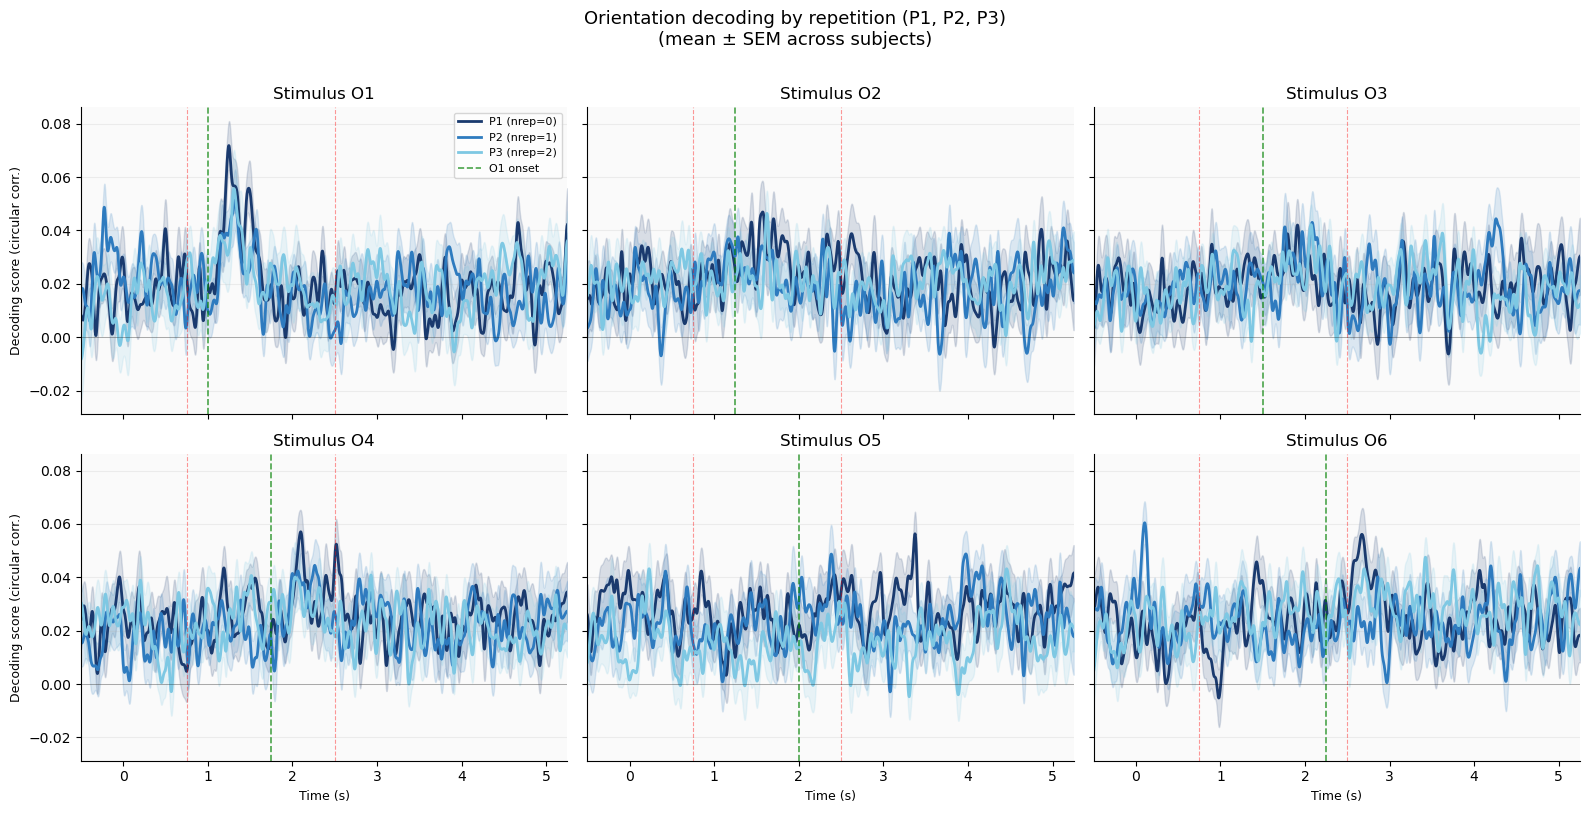

In [9]:
# DECODING DE ORIENTACION SEPARADO POR P1, P2, P3 
# mismo analisis que el decoding de decision pero para las orientaciones
# queremos ver si la representacion neural de cada estimulo (O1-O6)
# se debilita con las repeticiones — evidencia del sesgo de confirmacion
# en P1 esperamos curvas con picos claros en cada estimulo
# en P3 esperamos que esos picos sean mas pequeños

stim_cols = ['o1','o2','o3','o4','o5','o6']
bins_ori  = np.array([0, np.pi/4, np.pi/2, 3*np.pi/4])
n_stim    = 6

# array donde guardamos los scores (n_nreps × n_stim × n_sujetos × n_timepoints)
scorer_ori_nrep = np.zeros((len(nreps), n_stim, nSubj, n_time))

t_start = tm.time()

for isubj in range(nSubj):
    print(f'\nsubj {subjs_ok[isubj]} ({isubj+1}/{nSubj})')

    Y        = all_main_rawdata[isubj]['epoch_dat']
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)

    for i_nrep, nrep in enumerate(nreps):
        # seleccionamos solo los trials de este nrep
        idx_nrep = metadata[metadata['nrep'] == nrep].index.tolist()
        if len(idx_nrep) < n_folds * 2:
            continue

        Y_nrep    = Y[idx_nrep]
        meta_nrep = metadata.iloc[idx_nrep].reset_index(drop=True)

        for i_stim, col in enumerate(stim_cols):
            phi        = np.array(meta_nrep[col], dtype=float)
            phi_binned = np.digitize(phi % np.pi, bins_ori)
            folds      = create_folds(phi_binned, n_folds)

            # procesamos todos los timepoints en paralelo
            results_par = Parallel(n_jobs=-1)(
                delayed(decode_timepoint_ori)(it, Y_nrep, phi, folds)
                for it in range(n_time)
            )

            preds_all = np.column_stack(results_par)

            for it in range(n_time):
                valid = ~np.isnan(preds_all[:, it])
                scorer_ori_nrep[i_nrep, i_stim, isubj, it] = scorer_angle(
                    phi[valid], preds_all[valid, it]
                )

        print(f'  P{nrep+1} ✓', end='', flush=True)

    elapsed = (tm.time() - t_start) / 60
    print(f'  → {elapsed:.1f} min transcurridos')

print(f'\ndecoding de orientacion por P1/P2/P3 completado')

# guardamos resultados
results_ori = {
    'scorer_ori_nrep': scorer_ori_nrep,
    'time':            time,
    'subjs_ok':        subjs_ok,
    'stim_cols':       stim_cols,
}
save_path_ori = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/key_decoding_ori_nrep.pkl'
with open(save_path_ori, 'wb') as f:
    pickle.dump(results_ori, f)
print(f'resultados guardados en: {save_path_ori}')

# plot — 6 subplots (uno por estimulo) con 3 lineas (P1, P2, P3)
sigma = 10
scorer_smooth = gaussian_filter1d(scorer_ori_nrep, sigma=sigma, axis=3)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i_stim in range(n_stim):
    ax = axes[i_stim]

    for i_nrep in range(len(nreps)):
        mean = np.mean(scorer_smooth[i_nrep, i_stim], axis=0)
        sem  = np.std(scorer_smooth[i_nrep, i_stim], axis=0) / np.sqrt(nSubj)
        ax.plot(time, mean, color=plot_colors[i_nrep], lw=2, label=plot_labels[i_nrep])
        ax.fill_between(time, mean - sem, mean + sem,
                        color=plot_colors[i_nrep], alpha=0.15)

    # onset de este estimulo
    t_onset = 0.75 + 0.25 * (i_stim + 1)
    ax.axvline(t_onset, color='green', ls='--', lw=1.2, alpha=0.7, label=f'O{i_stim+1} onset')
    ax.axvline(0.75,             color='red', ls='--', lw=0.8, alpha=0.4)
    ax.axvline(0.75 + 0.25 * 7, color='red', ls='--', lw=0.8, alpha=0.4)
    ax.axhline(0, color='black', ls='-', lw=0.5, alpha=0.4)

    ax.set_title(f'Stimulus O{i_stim+1}', fontsize=12)
    ax.set_xlim([-0.5, 5.25])
    if i_stim in [0, 3]:
        ax.set_ylabel('Decoding score (circular corr.)', fontsize=9)
    if i_stim in [3, 4, 5]:
        ax.set_xlabel('Time (s)', fontsize=9)
    if i_stim == 0:
        ax.legend(fontsize=8)

fig.suptitle('Orientation decoding by repetition (P1, P2, P3)\n'
             '(mean ± SEM across subjects)', fontsize=13, y=1.01)
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2)
    ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()


subj s01 (1/26)
  P1 ✓  P2 ✓  P3 ✓  → 1.3 min transcurridos

subj s02 (2/26)
  P1 ✓  P2 ✓  P3 ✓  → 2.5 min transcurridos

subj s03 (3/26)
  P1 ✓  P2 ✓  P3 ✓  → 3.7 min transcurridos

subj s04 (4/26)
  P1 ✓  P2 ✓  P3 ✓  → 4.8 min transcurridos

subj s05 (5/26)
  P1 ✓  P2 ✓  P3 ✓  → 6.0 min transcurridos

subj s07 (6/26)
  P1 ✓  P2 ✓  P3 ✓  → 7.3 min transcurridos

subj s08 (7/26)
  P1 ✓  P2 ✓  P3 ✓  → 8.6 min transcurridos

subj s09 (8/26)
  P1 ✓  P2 ✓  P3 ✓  → 9.7 min transcurridos

subj s10 (9/26)
  P1 ✓  P2 ✓  P3 ✓  → 10.8 min transcurridos

subj s11 (10/26)
  P1 ✓  P2 ✓  P3 ✓  → 12.0 min transcurridos

subj s12 (11/26)
  P1 ✓  P2 ✓  P3 ✓  → 13.2 min transcurridos

subj s13 (12/26)
  P1 ✓  P2 ✓  P3 ✓  → 14.3 min transcurridos

subj s14 (13/26)
  P1 ✓  P2 ✓  P3 ✓  → 15.6 min transcurridos

subj s15 (14/26)
  P1 ✓  P2 ✓  P3 ✓  → 16.8 min transcurridos

subj s16 (15/26)
  P1 ✓  P2 ✓  P3 ✓  → 17.9 min transcurridos

subj s17 (16/26)
  P1 ✓  P2 ✓  P3 ✓  → 19.0 min transcurridos

subj s18

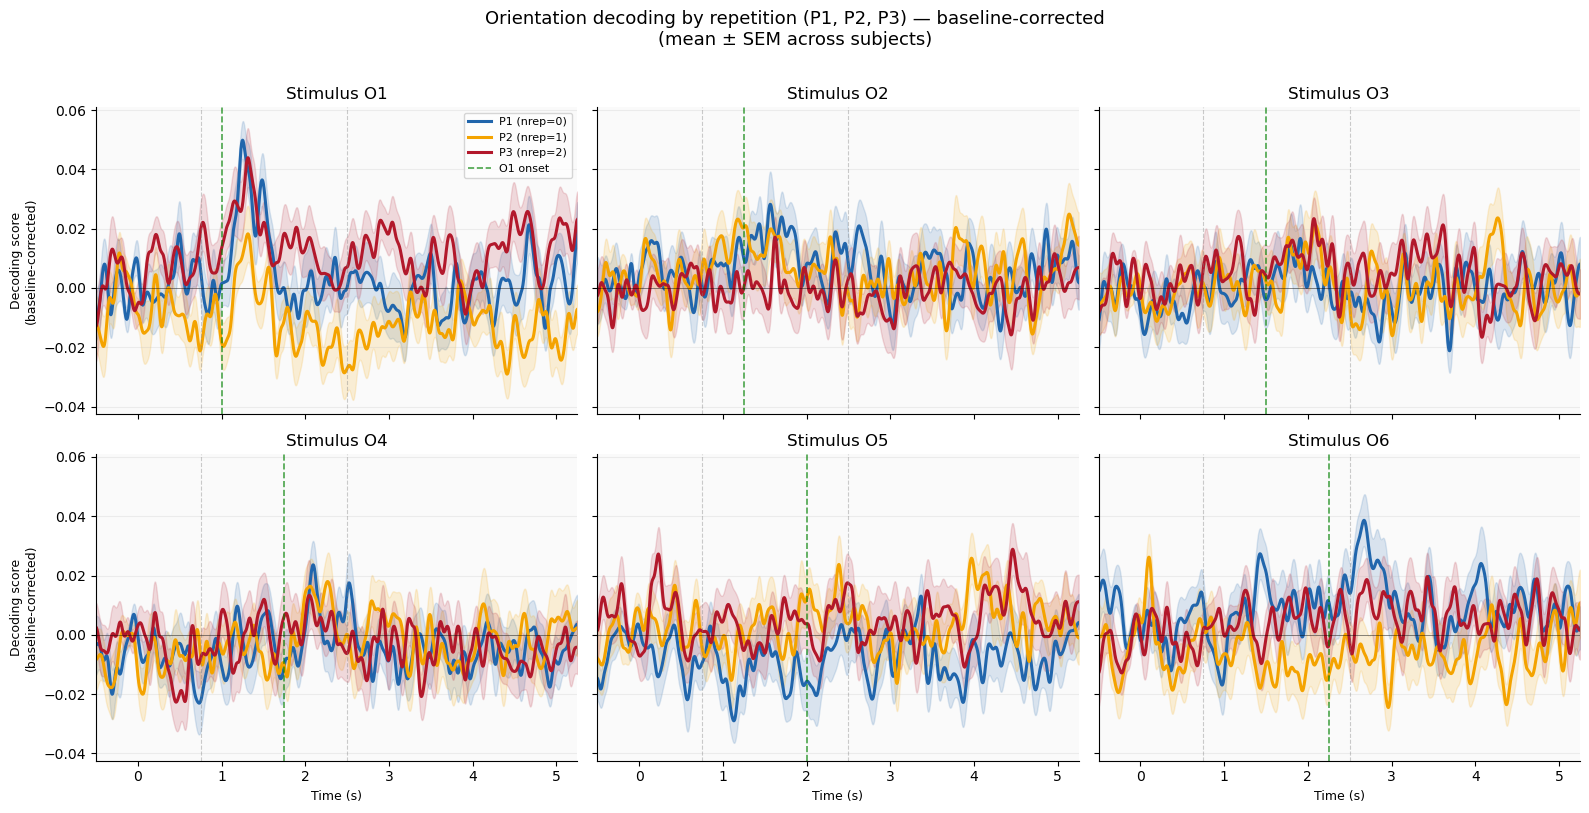

In [ ]:
# DECODING DE ORIENTACION SEPARADO POR P1, P2, P3 
# mismo analisis que el decoding de decision pero para las orientaciones
# queremos ver si la representacion neural de cada estimulo (O1-O6)
# se debilita con las repeticiones — evidencia del sesgo de confirmacion
# en P1 esperamos curvas con picos claros en cada estimulo
# en P3 esperamos que esos picos sean mas pequeños

stim_cols = ['o1','o2','o3','o4','o5','o6']
bins_ori  = np.array([0, np.pi/4, np.pi/2, 3*np.pi/4])
n_stim    = 6

# array donde guardamos los scores (n_nreps × n_stim × n_sujetos × n_timepoints)
scorer_ori_nrep = np.zeros((len(nreps), n_stim, nSubj, n_time))

t_start = tm.time()

for isubj in range(nSubj):
    print(f'\nsubj {subjs_ok[isubj]} ({isubj+1}/{nSubj})')

    Y        = all_main_rawdata[isubj]['epoch_dat']
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)

    for i_nrep, nrep in enumerate(nreps):
        # seleccionamos solo los trials de este nrep
        idx_nrep = metadata[metadata['nrep'] == nrep].index.tolist()
        if len(idx_nrep) < n_folds * 2:
            continue

        Y_nrep    = Y[idx_nrep]
        meta_nrep = metadata.iloc[idx_nrep].reset_index(drop=True)

        for i_stim, col in enumerate(stim_cols):
            phi        = np.array(meta_nrep[col], dtype=float)
            phi_binned = np.digitize(phi % np.pi, bins_ori)
            folds      = create_folds(phi_binned, n_folds)

            # procesamos todos los timepoints en paralelo
            results_par = Parallel(n_jobs=-1)(
                delayed(decode_timepoint_ori)(it, Y_nrep, phi, folds)
                for it in range(n_time)
            )

            preds_all = np.column_stack(results_par)

            for it in range(n_time):
                valid = ~np.isnan(preds_all[:, it])
                scorer_ori_nrep[i_nrep, i_stim, isubj, it] = scorer_angle(
                    phi[valid], preds_all[valid, it]
                )

        print(f'  P{nrep+1} ✓', end='', flush=True)

    elapsed = (tm.time() - t_start) / 60
    print(f'  → {elapsed:.1f} min transcurridos')

print(f'\ndecoding de orientacion por P1/P2/P3 completado')

# guardamos resultados
results_ori = {
    'scorer_ori_nrep': scorer_ori_nrep,
    'time':            time,
    'subjs_ok':        subjs_ok,
    'stim_cols':       stim_cols,
}
save_path_ori = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/key_decoding_ori_nrep.pkl'
with open(save_path_ori, 'wb') as f:
    pickle.dump(results_ori, f)
print(f'resultados guardados en: {save_path_ori}')

# BASELINE CORRECTION 
# restamos la media del periodo pre-estimulo (-0.2s a 0s) a cada curva
# esto elimina diferencias de offset entre P1/P2/P3 que no son de interes
# y deja solo el cambio relativo al baseline de cada condicion
idx_baseline = np.where((time >= -0.2) & (time <= 0))[0]
baseline_vals = np.mean(scorer_ori_nrep[:, :, :, idx_baseline], axis=3, keepdims=True)
scorer_ori_nrep_bc = scorer_ori_nrep - baseline_vals

# SMOOTHING 
# aumentamos un poco el sigma para mejorar la relacion señal-ruido
# dado que ahora cada condicion tiene menos trials (~87) el ruido es mayor
sigma = 15
scorer_smooth = gaussian_filter1d(scorer_ori_nrep_bc, sigma=sigma, axis=3)

plot_colors = ['#2166ac', '#f4a300', '#b2182b']
plot_labels = ['P1 (nrep=0)', 'P2 (nrep=1)', 'P3 (nrep=2)']

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i_stim in range(n_stim):
    ax = axes[i_stim]

    for i_nrep in range(len(nreps)):
        mean = np.mean(scorer_smooth[i_nrep, i_stim], axis=0)
        sem  = np.std(scorer_smooth[i_nrep, i_stim], axis=0) / np.sqrt(nSubj)
        ax.plot(time, mean, color=plot_colors[i_nrep], lw=2.2, label=plot_labels[i_nrep])
        ax.fill_between(time, mean - sem, mean + sem,
                        color=plot_colors[i_nrep], alpha=0.15)

    # onset de este estimulo
    t_onset = 0.75 + 0.25 * (i_stim + 1)
    ax.axvline(t_onset, color='green', ls='--', lw=1.2, alpha=0.7, label=f'O{i_stim+1} onset')
    ax.axvline(0.75,             color='gray', ls='--', lw=0.8, alpha=0.4)
    ax.axvline(0.75 + 0.25 * 7, color='gray', ls='--', lw=0.8, alpha=0.4)
    ax.axhline(0, color='black', ls='-', lw=0.6, alpha=0.5)

    ax.set_title(f'Stimulus O{i_stim+1}', fontsize=12)
    ax.set_xlim([-0.5, 5.25])
    if i_stim in [0, 3]:
        ax.set_ylabel('Decoding score\n(baseline-corrected)', fontsize=9)
    if i_stim in [3, 4, 5]:
        ax.set_xlabel('Time (s)', fontsize=9)
    if i_stim == 0:
        ax.legend(fontsize=8)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2)
    ax.set_facecolor('#fafafa')

fig.suptitle('Orientation decoding by repetition (P1, P2, P3) — baseline-corrected\n'
             '(mean ± SEM across subjects)', fontsize=13, y=1.01)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

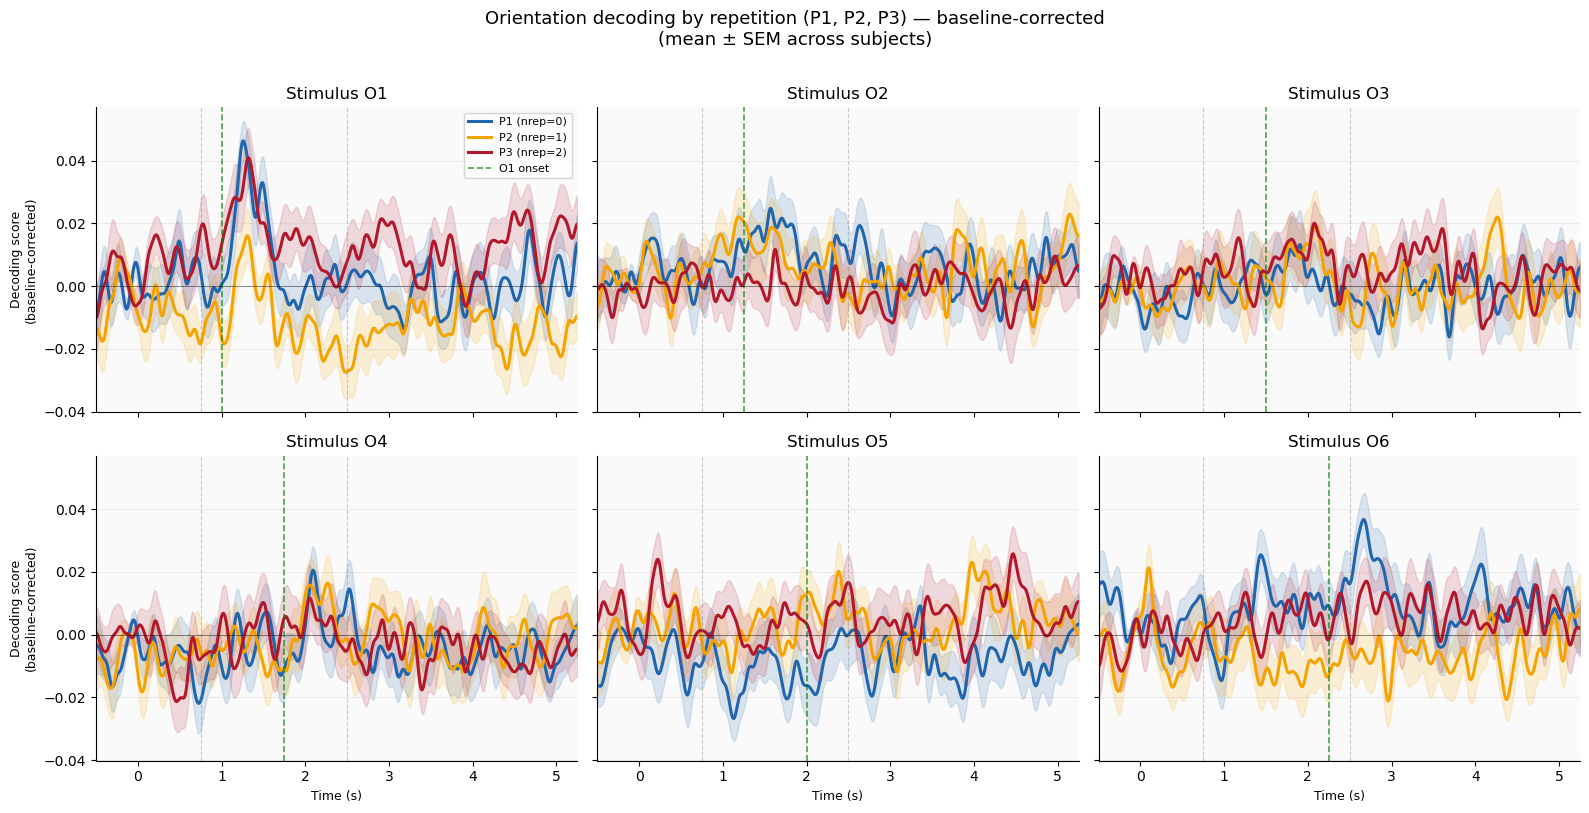

In [ ]:
# BASELINE CORRECTION 
idx_baseline = np.where((time >= -0.2) & (time <= 0))[0]
baseline_vals = np.mean(scorer_ori_nrep[:, :, :, idx_baseline], axis=3, keepdims=True)
scorer_ori_nrep_bc = scorer_ori_nrep - baseline_vals

# SMOOTHING 
sigma = 20  # subimos el sigma para mas smoothing
scorer_smooth = gaussian_filter1d(scorer_ori_nrep_bc, sigma=sigma, axis=3)

plot_colors = ['#2166ac', '#f4a300', '#b2182b']
plot_labels = ['P1 (nrep=0)', 'P2 (nrep=1)', 'P3 (nrep=2)']

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i_stim in range(n_stim):
    ax = axes[i_stim]

    for i_nrep in range(len(nreps)):
        mean = np.mean(scorer_smooth[i_nrep, i_stim], axis=0)
        sem  = np.std(scorer_smooth[i_nrep, i_stim], axis=0) / np.sqrt(nSubj)
        ax.plot(time, mean, color=plot_colors[i_nrep], lw=2.2, label=plot_labels[i_nrep])
        ax.fill_between(time, mean - sem, mean + sem,
                        color=plot_colors[i_nrep], alpha=0.15)

    t_onset = 0.75 + 0.25 * (i_stim + 1)
    ax.axvline(t_onset, color='green', ls='--', lw=1.2, alpha=0.7, label=f'O{i_stim+1} onset')
    ax.axvline(0.75,             color='gray', ls='--', lw=0.8, alpha=0.4)
    ax.axvline(0.75 + 0.25 * 7, color='gray', ls='--', lw=0.8, alpha=0.4)
    ax.axhline(0, color='black', ls='-', lw=0.6, alpha=0.5)

    ax.set_title(f'Stimulus O{i_stim+1}', fontsize=12)
    ax.set_xlim([-0.5, 5.25])
    if i_stim in [0, 3]:
        ax.set_ylabel('Decoding score\n(baseline-corrected)', fontsize=9)
    if i_stim in [3, 4, 5]:
        ax.set_xlabel('Time (s)', fontsize=9)
    if i_stim == 0:
        ax.legend(fontsize=8)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2)
    ax.set_facecolor('#fafafa')

fig.suptitle('Orientation decoding by repetition (P1, P2, P3) — baseline-corrected\n'
             '(mean ± SEM across subjects)', fontsize=13, y=1.01)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()


subj s01 (1/26)
  congruencia calculada ✓
  → 0.8 min transcurridos

subj s02 (2/26)
  congruencia calculada ✓
  → 1.6 min transcurridos

subj s03 (3/26)
  congruencia calculada ✓
  → 2.4 min transcurridos

subj s04 (4/26)
  congruencia calculada ✓
  → 3.2 min transcurridos

subj s05 (5/26)
  congruencia calculada ✓
  → 4.0 min transcurridos

subj s07 (6/26)
  congruencia calculada ✓
  → 4.9 min transcurridos

subj s08 (7/26)
  congruencia calculada ✓
  → 5.7 min transcurridos

subj s09 (8/26)
  congruencia calculada ✓
  → 6.4 min transcurridos

subj s10 (9/26)
  congruencia calculada ✓
  → 7.2 min transcurridos

subj s11 (10/26)
  congruencia calculada ✓
  → 8.0 min transcurridos

subj s12 (11/26)
  congruencia calculada ✓
  → 8.8 min transcurridos

subj s13 (12/26)
  congruencia calculada ✓
  → 9.8 min transcurridos

subj s14 (13/26)
  congruencia calculada ✓
  → 10.7 min transcurridos

subj s15 (14/26)
  congruencia calculada ✓
  → 11.6 min transcurridos

subj s16 (15/26)
  congrue

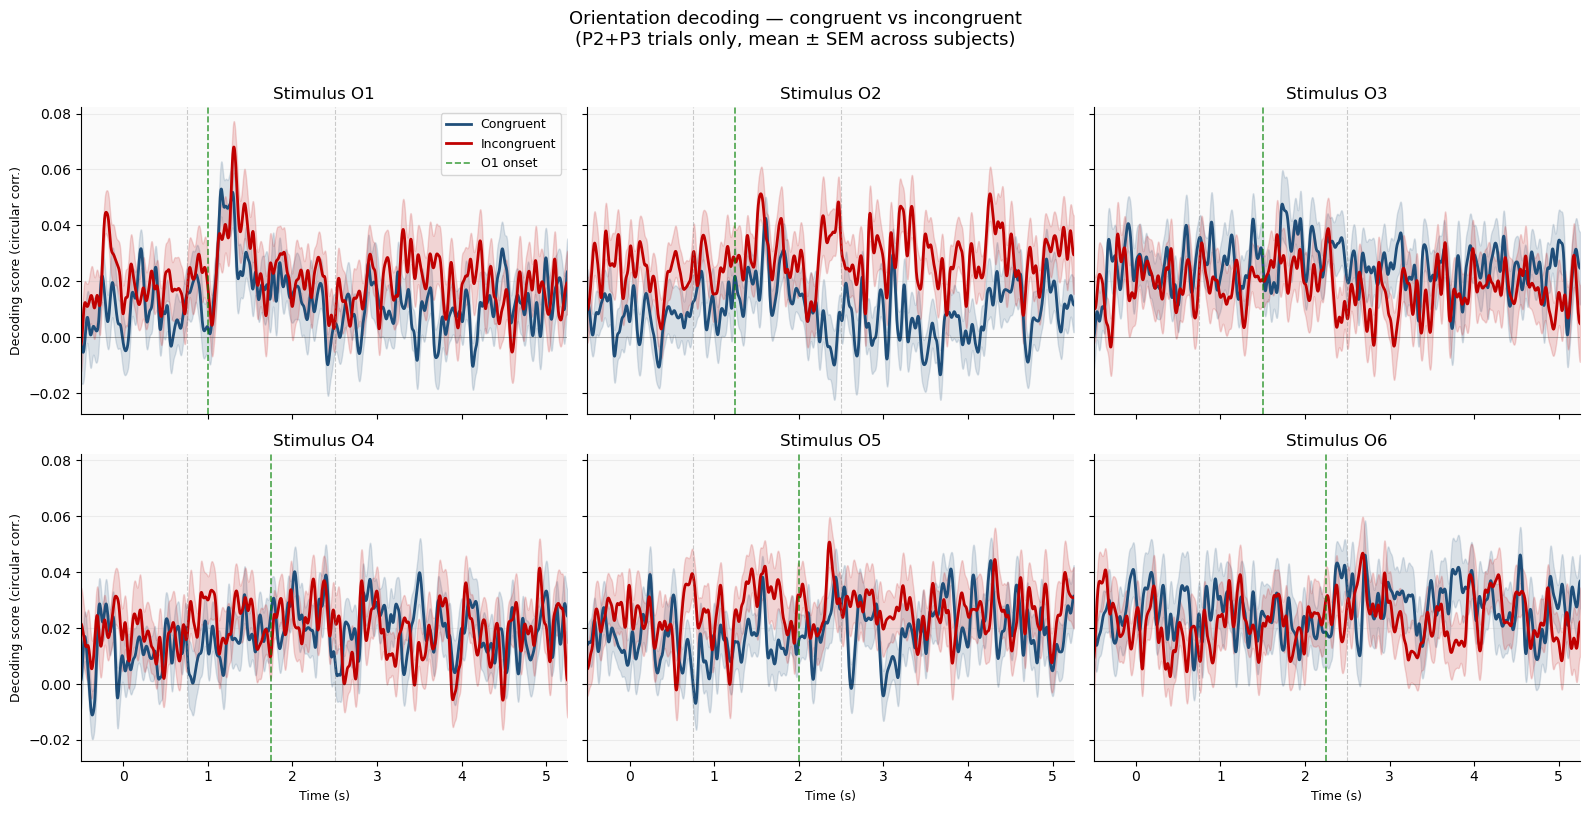

In [ ]:
# DECODING DE ORIENTACION: CONGRUENTE VS INCONGRUENTE 
# para cada trial de P2 y P3, clasificamos cada estimulo como congruente o
# incongruente con respecto a la decision tomada en la secuencia anterior (deci-1)
# congruente: la orientacion del estimulo apunta en la misma direccion que deci-1
# incongruente: la orientacion contradice deci-1
# esperamos que los estimulos incongruentes tengan mayor decoding
# porque el cerebro los procesa con mas atencion al violar la expectativa

# como definimos congruencia 
# deci-1 = 1 (cardinal): orientaciones cerca de 0° o 90° son congruentes
# deci-1 = 0 (diagonal): orientaciones cerca de 45° o 135° son congruentes
# usamos el bin de 45° para clasificar cada orientacion:
# bins 1 y 3 (cerca de 0° y 90°) → mas cardinal
# bins 2 y 4 (cerca de 45° y 135°) → mas diagonal

def get_congruence(phi, deci_prev):
    # phi: orientacion en radianes
    # deci_prev: decision previa (0=diagonal, 1=cardinal)
    # devuelve array booleano: True = congruente, False = incongruente
    bins_ori  = np.array([0, np.pi/4, np.pi/2, 3*np.pi/4])
    phi_bin   = np.digitize(phi % np.pi, bins_ori)  # 1,2,3,4
    # bins 1 y 3 → cerca de 0° y 90° → cardinal
    # bins 2 y 4 → cerca de 45° y 135° → diagonal
    is_cardinal = np.isin(phi_bin, [1, 3])
    is_diagonal = np.isin(phi_bin, [2, 4])
    congruent = np.where(
        deci_prev == 1,  # si la decision previa fue cardinal
        is_cardinal,     # congruente si el estimulo es cardinal
        is_diagonal      # congruente si el estimulo es diagonal
    )
    return congruent

# solo tiene sentido para P2 y P3 (nrep=1 y nrep=2) porque necesitamos deci-1
nreps_cong   = [1, 2]
plot_labels_cong = ['Congruent', 'Incongruent']
plot_colors_cong = ['#1f4e79', '#c00000']

# array donde guardamos (congruente/incongruente × n_stim × n_sujetos × n_timepoints)
scorer_cong = np.zeros((2, n_stim, nSubj, n_time))  # 0=congruente, 1=incongruente
count_cong  = np.zeros((2, n_stim, nSubj))  # para saber cuantos trials hay en cada condicion

t_start = tm.time()

for isubj in range(nSubj):
    print(f'\nsubj {subjs_ok[isubj]} ({isubj+1}/{nSubj})')

    Y        = all_main_rawdata[isubj]['epoch_dat']
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)

    # cogemos solo P2 y P3 (nrep=1 y nrep=2) — necesitamos deci-1
    idx_p2p3 = metadata[metadata['nrep'].isin(nreps_cong)].index.tolist()
    if len(idx_p2p3) < n_folds * 2:
        print(f'  pocos trials P2+P3, se omite')
        continue

    Y_p2p3    = Y[idx_p2p3]
    meta_p2p3 = metadata.iloc[idx_p2p3].reset_index(drop=True)
    deci_prev = np.array(meta_p2p3['deci-1'], dtype=int)  # decision previa

    for i_stim, col in enumerate(stim_cols):
        phi = np.array(meta_p2p3[col], dtype=float)

        # calculamos congruencia para cada trial
        congruent = get_congruence(phi, deci_prev)

        # indices de trials congruentes e incongruentes
        idx_con  = np.where(congruent)[0]
        idx_inco = np.where(~congruent)[0]

        count_cong[0, i_stim, isubj] = len(idx_con)
        count_cong[1, i_stim, isubj] = len(idx_inco)

        for i_cond, (idx_cond, label) in enumerate(zip(
            [idx_con, idx_inco], ['congruente', 'incongruente']
        )):
            if len(idx_cond) < n_folds * 2:
                print(f'  O{i_stim+1} {label}: pocos trials ({len(idx_cond)}), se omite')
                continue

            Y_cond  = Y_p2p3[idx_cond]
            phi_cond = phi[idx_cond]

            phi_binned = np.digitize(phi_cond % np.pi, bins_ori)
            # verificamos que hay suficientes trials por bin
            if len(np.unique(phi_binned)) < 2:
                continue

            folds = create_folds(phi_binned, n_folds)

            results_par = Parallel(n_jobs=-1)(
                delayed(decode_timepoint_ori)(it, Y_cond, phi_cond, folds)
                for it in range(n_time)
            )

            preds_all = np.column_stack(results_par)

            for it in range(n_time):
                valid = ~np.isnan(preds_all[:, it])
                scorer_cong[i_cond, i_stim, isubj, it] = scorer_angle(
                    phi_cond[valid], preds_all[valid, it]
                )

    print(f'  congruencia calculada ✓', flush=True)
    elapsed = (tm.time() - t_start) / 60
    print(f'  → {elapsed:.1f} min transcurridos')

print(f'\ndecoding congruente/incongruente completado')

# info sobre cuantos trials hay en cada condicion
print(f'\nTrials medios por condicion:')
print(f'  Congruente:   {count_cong[0].mean():.1f} trials por sujeto y estimulo')
print(f'  Incongruente: {count_cong[1].mean():.1f} trials por sujeto y estimulo')

# guardamos resultados
results_cong = {
    'scorer_cong': scorer_cong,
    'time':        time,
    'subjs_ok':    subjs_ok,
    'stim_cols':   stim_cols,
}
save_path_cong = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/key_decoding_congruence.pkl'
with open(save_path_cong, 'wb') as f:
    pickle.dump(results_cong, f)
print(f'resultados guardados en: {save_path_cong}')

# plot — 6 subplots (uno por estimulo) con 2 lineas (congruente vs incongruente)
sigma = 10
scorer_smooth = gaussian_filter1d(scorer_cong, sigma=sigma, axis=3)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i_stim in range(n_stim):
    ax = axes[i_stim]

    for i_cond in range(2):
        mean = np.mean(scorer_smooth[i_cond, i_stim], axis=0)
        sem  = np.std(scorer_smooth[i_cond, i_stim], axis=0) / np.sqrt(nSubj)
        ax.plot(time, mean, color=plot_colors_cong[i_cond], lw=2,
                label=plot_labels_cong[i_cond])
        ax.fill_between(time, mean - sem, mean + sem,
                        color=plot_colors_cong[i_cond], alpha=0.15)

    t_onset = 0.75 + 0.25 * (i_stim + 1)
    ax.axvline(t_onset, color='green', ls='--', lw=1.2, alpha=0.7,
               label=f'O{i_stim+1} onset')
    ax.axvline(0.75,             color='gray', ls='--', lw=0.8, alpha=0.4)
    ax.axvline(0.75 + 0.25 * 7, color='gray', ls='--', lw=0.8, alpha=0.4)
    ax.axhline(0, color='black', ls='-', lw=0.5, alpha=0.4)

    ax.set_title(f'Stimulus O{i_stim+1}', fontsize=12)
    ax.set_xlim([-0.5, 5.25])
    if i_stim in [0, 3]:
        ax.set_ylabel('Decoding score (circular corr.)', fontsize=9)
    if i_stim in [3, 4, 5]:
        ax.set_xlabel('Time (s)', fontsize=9)
    if i_stim == 0:
        ax.legend(fontsize=9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2)
    ax.set_facecolor('#fafafa')

fig.suptitle('Orientation decoding — congruent vs incongruent\n'
             '(P2+P3 trials only, mean ± SEM across subjects)', fontsize=13, y=1.01)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

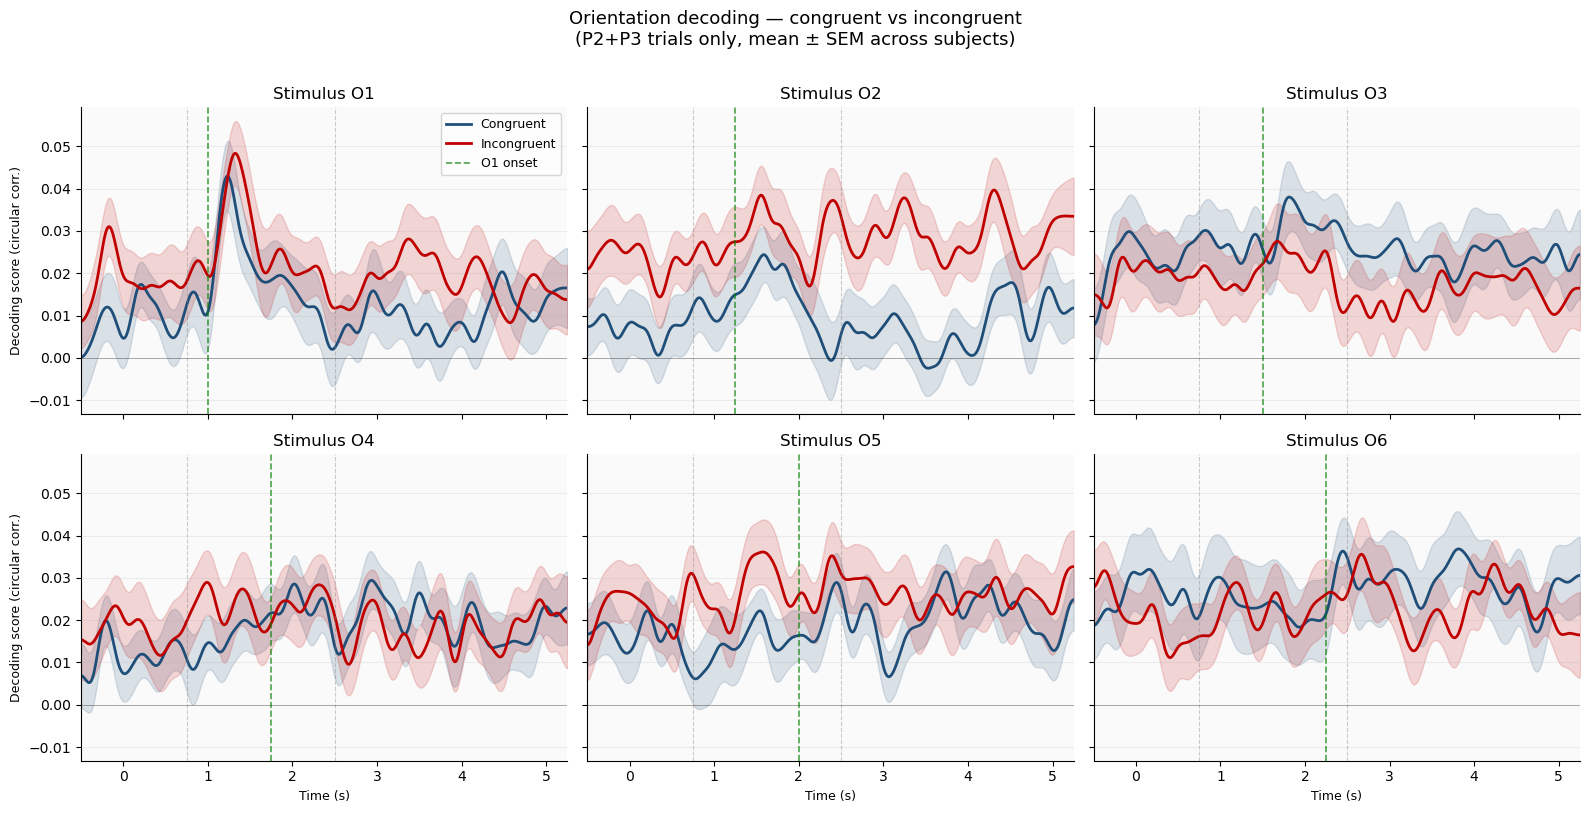

In [33]:
# plot — 6 subplots (uno por estimulo) con 2 lineas (congruente vs incongruente)
sigma = 40  # subimos el sigma para mas smoothing
scorer_smooth = gaussian_filter1d(scorer_cong, sigma=sigma, axis=3)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i_stim in range(n_stim):
    ax = axes[i_stim]

    for i_cond in range(2):
        mean = np.mean(scorer_smooth[i_cond, i_stim], axis=0)
        sem  = np.std(scorer_smooth[i_cond, i_stim], axis=0) / np.sqrt(nSubj)
        ax.plot(time, mean, color=plot_colors_cong[i_cond], lw=2,
                label=plot_labels_cong[i_cond])
        ax.fill_between(time, mean - sem, mean + sem,
                        color=plot_colors_cong[i_cond], alpha=0.15)

    t_onset = 0.75 + 0.25 * (i_stim + 1)
    ax.axvline(t_onset, color='green', ls='--', lw=1.2, alpha=0.7,
               label=f'O{i_stim+1} onset')
    ax.axvline(0.75,             color='gray', ls='--', lw=0.8, alpha=0.4)
    ax.axvline(0.75 + 0.25 * 7, color='gray', ls='--', lw=0.8, alpha=0.4)
    ax.axhline(0, color='black', ls='-', lw=0.5, alpha=0.4)

    ax.set_title(f'Stimulus O{i_stim+1}', fontsize=12)
    ax.set_xlim([-0.5, 5.25])
    if i_stim in [0, 3]:
        ax.set_ylabel('Decoding score (circular corr.)', fontsize=9)
    if i_stim in [3, 4, 5]:
        ax.set_xlabel('Time (s)', fontsize=9)
    if i_stim == 0:
        ax.legend(fontsize=9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2)
    ax.set_facecolor('#fafafa')

fig.suptitle('Orientation decoding — congruent vs incongruent\n'
             '(P2+P3 trials only, mean ± SEM across subjects)', fontsize=13, y=1.01)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()


subj s01 (1/26)
  congruencia decision calculada ✓
  → 0.1 min transcurridos

subj s02 (2/26)
  congruencia decision calculada ✓
  → 0.2 min transcurridos

subj s03 (3/26)
  congruencia decision calculada ✓
  → 0.2 min transcurridos

subj s04 (4/26)
  congruencia decision calculada ✓
  → 0.3 min transcurridos

subj s05 (5/26)
  congruencia decision calculada ✓
  → 0.4 min transcurridos

subj s07 (6/26)
  congruencia decision calculada ✓
  → 0.4 min transcurridos

subj s08 (7/26)
  congruencia decision calculada ✓
  → 0.5 min transcurridos

subj s09 (8/26)
  congruencia decision calculada ✓
  → 0.6 min transcurridos

subj s10 (9/26)
  congruencia decision calculada ✓
  → 0.6 min transcurridos

subj s11 (10/26)
  congruencia decision calculada ✓
  → 0.7 min transcurridos

subj s12 (11/26)
  congruencia decision calculada ✓
  → 0.8 min transcurridos

subj s13 (12/26)
  congruencia decision calculada ✓
  → 0.8 min transcurridos

subj s14 (13/26)
  congruencia decision calculada ✓
  → 0.9 

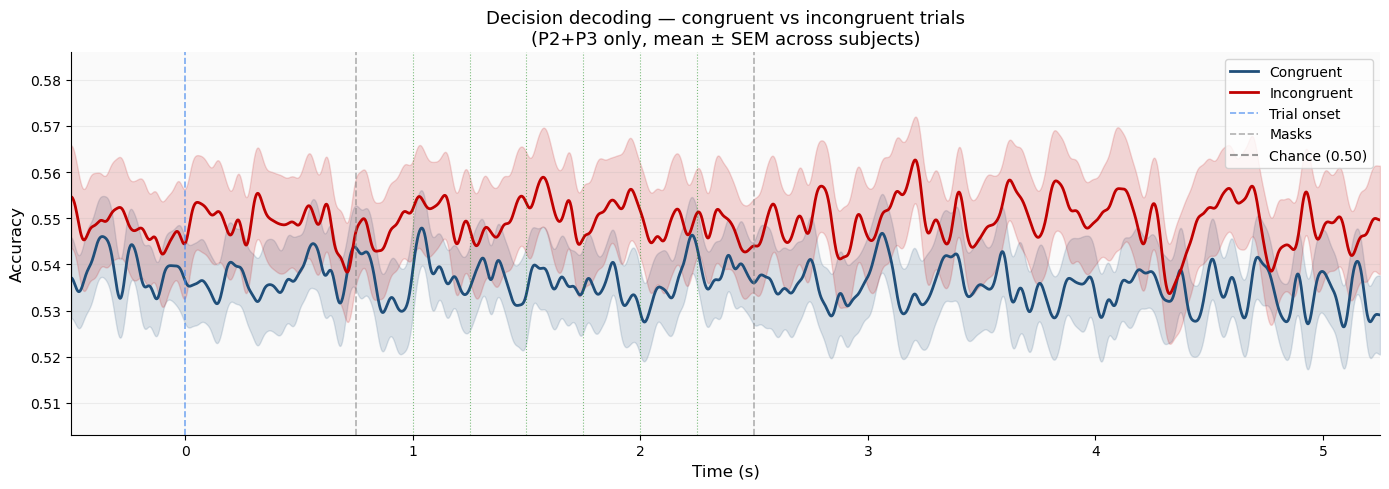

In [ ]:
# DECODING DE DECISION: CONGRUENTE VS INCONGRUENTE 
# mismo analisis de congruencia pero ahora para la decision en vez de la orientacion
# queremos ver si el clasificador predice mejor la decision cuando los estimulos
# son incongruentes con la decision previa (el cerebro esta mas "alerta")
# que cuando son congruentes (el cerebro procesa de forma mas superficial)

# para cada trial de P2 y P3, definimos si el trial es mayoritariamente
# congruente o incongruente con la decision previa
# un trial es congruente si la mayoria de sus 6 estimulos son congruentes con deci-1

def get_trial_congruence(metadata_subset):
    # calcula si cada trial es mayoritariamente congruente o incongruente
    # con respecto a la decision previa (deci-1)
    deci_prev  = np.array(metadata_subset['deci-1'], dtype=int)
    bins_ori   = np.array([0, np.pi/4, np.pi/2, 3*np.pi/4])
    stim_cols  = ['o1','o2','o3','o4','o5','o6']

    n_trials     = len(metadata_subset)
    n_congruent  = np.zeros(n_trials)

    for col in stim_cols:
        phi      = np.array(metadata_subset[col], dtype=float)
        phi_bin  = np.digitize(phi % np.pi, bins_ori)
        is_card  = np.isin(phi_bin, [1, 3])
        is_diag  = np.isin(phi_bin, [2, 4])
        cong     = np.where(deci_prev == 1, is_card, is_diag)
        n_congruent += cong.astype(int)

    # trial congruente si la mayoria de estimulos (>3 de 6) son congruentes
    trial_congruent = n_congruent > 3
    return trial_congruent

# array donde guardamos la accuracy (congruente/incongruente × n_sujetos × n_timepoints)
scorer_deci_cong = np.zeros((2, nSubj, n_time))
count_deci_cong  = np.zeros((2, nSubj))

t_start = tm.time()

for isubj in range(nSubj):
    print(f'\nsubj {subjs_ok[isubj]} ({isubj+1}/{nSubj})')

    Y        = all_main_rawdata[isubj]['epoch_dat']
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)
    deci     = np.array(metadata['deci'], dtype=int)

    # cogemos solo P2 y P3
    idx_p2p3  = metadata[metadata['nrep'].isin([1, 2])].index.tolist()
    if len(idx_p2p3) < n_folds * 2:
        continue

    Y_p2p3    = Y[idx_p2p3]
    meta_p2p3 = metadata.iloc[idx_p2p3].reset_index(drop=True)
    deci_p2p3 = deci[idx_p2p3]

    # calculamos congruencia a nivel de trial
    trial_cong = get_trial_congruence(meta_p2p3)

    idx_con  = np.where(trial_cong)[0]
    idx_inco = np.where(~trial_cong)[0]

    count_deci_cong[0, isubj] = len(idx_con)
    count_deci_cong[1, isubj] = len(idx_inco)

    for i_cond, idx_cond in enumerate([idx_con, idx_inco]):
        if len(idx_cond) < n_folds * 2:
            print(f'  {"congruente" if i_cond==0 else "incongruente"}: pocos trials ({len(idx_cond)}), se omite')
            continue

        Y_cond    = Y_p2p3[idx_cond]
        deci_cond = deci_p2p3[idx_cond]

        if len(np.unique(deci_cond)) < 2:
            continue

        folds = create_folds(deci_cond, n_folds)

        results_par = Parallel(n_jobs=-1)(
            delayed(decode_timepoint_deci)(it, Y_cond, deci_cond, folds)
            for it in range(n_time)
        )

        preds_all = np.column_stack(results_par)

        for it in range(n_time):
            valid = ~np.isnan(preds_all[:, it])
            scorer_deci_cong[i_cond, isubj, it] = np.mean(
                preds_all[valid, it] == deci_cond[valid].astype(float)
            )

    print(f'  congruencia decision calculada ✓', flush=True)
    elapsed = (tm.time() - t_start) / 60
    print(f'  → {elapsed:.1f} min transcurridos')

print(f'\ndecoding decision congruente/incongruente completado')
print(f'Trials medios congruentes:   {count_deci_cong[0].mean():.1f}')
print(f'Trials medios incongruentes: {count_deci_cong[1].mean():.1f}')

# guardamos resultados
results_deci_cong = {
    'scorer_deci_cong': scorer_deci_cong,
    'time':             time,
    'subjs_ok':         subjs_ok,
}
save_path_deci_cong = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/key_decoding_deci_congruence.pkl'
with open(save_path_deci_cong, 'wb') as f:
    pickle.dump(results_deci_cong, f)
print(f'resultados guardados en: {save_path_deci_cong}')

# plot
sigma = 10
scorer_smooth = gaussian_filter1d(scorer_deci_cong, sigma=sigma, axis=2)

fig, ax = plt.subplots(figsize=(14, 5))

for i_cond in range(2):
    mean = np.mean(scorer_smooth[i_cond], axis=0)
    sem  = np.std(scorer_smooth[i_cond], axis=0) / np.sqrt(nSubj)
    ax.plot(time, mean, color=plot_colors_cong[i_cond], lw=2,
            label=plot_labels_cong[i_cond])
    ax.fill_between(time, mean - sem, mean + sem,
                    color=plot_colors_cong[i_cond], alpha=0.15)

ax.axvline(0,                color='#4488EE', ls='--', lw=1.2, alpha=0.7, label='Trial onset')
ax.axvline(0.75,             color='gray',    ls='--', lw=1.2, alpha=0.6, label='Masks')
ax.axvline(0.75 + 0.25 * 7, color='gray',    ls='--', lw=1.2, alpha=0.6)
for istim in range(6):
    ax.axvline(0.75 + 0.25 * (istim + 1), color='green', ls=':', lw=0.8, alpha=0.5)

ax.axhline(0.5, color='gray', ls='--', lw=1.5, alpha=0.8, label='Chance (0.50)')

all_means = [np.mean(scorer_smooth[i], axis=0) for i in range(2)]
all_sems  = [np.std(scorer_smooth[i], axis=0) / np.sqrt(nSubj) for i in range(2)]
y_min = min(m.min() for m in all_means) - max(s.max() for s in all_sems) - 0.01
y_max = max(m.max() for m in all_means) + max(s.max() for s in all_sems) + 0.01
ax.set_ylim([max(0.45, y_min), min(0.70, y_max)])
ax.set_xlim([-0.5, 5.25])

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Decision decoding — congruent vs incongruent trials\n'
             '(P2+P3 only, mean ± SEM across subjects)', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()